In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sn

In [ ]:
df = pd.read_csv('/content/sample_data/banking.csv')

In [ ]:
df


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59,retired,married,high.school,unknown,no,yes,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
41184,31,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
41185,42,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
41186,48,technician,married,professional.course,no,no,yes,telephone,oct,tue,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0


In [ ]:
df.shape

(41188, 21)

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [ ]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
41183,59,retired,married,high.school,unknown,no,yes,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
41184,31,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
41185,42,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
41186,48,technician,married,professional.course,no,no,yes,telephone,oct,tue,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0
41187,25,student,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,0


In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [ ]:
df['age']= pd.to_numeric(df['age'],errors='coerce')

In [ ]:
df.duplicated().sum()

np.int64(12)

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
17977,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,0
19339,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
24769,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,0
25634,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0
28143,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,0
29352,71,retired,single,university.degree,no,no,no,telephone,oct,tue,...,1,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0
29936,45,admin.,married,university.degree,no,no,no,cellular,jul,thu,...,1,999,0,nonexistent,-2.9,92.469,-33.6,1.072,5076.2,1
34333,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0
37154,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
39423,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0


In [ ]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_%': df.isnull().mean() * 100
})


In [ ]:
missing[missing['Missing_Count'] > 0].sort_values(
    'Missing_%', ascending=False
)

,Missing_Count,Missing_%


In [ ]:
categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day_of_week',
    'poutcome',
    'y'
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

 marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

 education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

 default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

 housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

 loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

 contact
con

In [ ]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


job:
['blue-collar' 'technician' 'management' 'services' 'retired' 'admin.'
 'housemaid' 'unemployed' 'entrepreneur' 'self-employed' 'unknown'
 'student']

marital:
['married' 'single' 'divorced' 'unknown']

education:
['basic.4y' 'unknown' 'university.degree' 'high.school' 'basic.9y'
 'professional.course' 'basic.6y' 'illiterate']

default:
['unknown' 'no' 'yes']

housing:
['yes' 'no' 'unknown']

loan:
['no' 'yes' 'unknown']

contact:
['cellular' 'telephone']

month:
['aug' 'nov' 'jun' 'apr' 'jul' 'may' 'oct' 'mar' 'sep' 'dec']

day_of_week:
['thu' 'fri' 'tue' 'mon' 'wed']

poutcome:
['nonexistent' 'success' 'failure']

y:
[0 1]


In [ ]:
df['age'].describe()
df[(df['age']<18)| (df['age']>100)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
16808,17,student,single,basic.9y,no,unknown,unknown,cellular,aug,fri,...,2,999,1,failure,-2.9,92.201,-31.4,0.869,5076.2,1
34675,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,2,999,2,failure,-2.9,92.201,-31.4,0.869,5076.2,0
36388,17,student,single,unknown,no,yes,no,cellular,aug,wed,...,3,4,2,success,-2.9,92.201,-31.4,0.884,5076.2,0
40271,17,student,single,unknown,no,no,yes,cellular,oct,tue,...,1,2,2,success,-3.4,92.431,-26.9,0.742,5017.5,1
40555,17,student,single,basic.9y,no,yes,no,cellular,aug,fri,...,3,4,2,success,-2.9,92.201,-31.4,0.869,5076.2,0


In [ ]:
df['campaign'].describe()

,campaign
count,41188.000000
mean,2.567593
std,2.770014
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,56.000000


In [ ]:
df['campaign'].sort_values(ascending=False).head(20)

,campaign
20005,56
31185,43
7663,43
18901,42
40111,42
1782,41
933,40
6343,40
2496,39
40264,37


In [ ]:
df['pdays'].value_counts().head()

,count
pdays,
999,39673
3,439
6,412
4,118
9,64


In [ ]:
(df['pdays']==999).sum()

np.int64(39673)

In [ ]:
(df['pdays']==999).mean()*100

np.float64(96.32174419733903)

In [ ]:
df['previously_contacted'] = np.where(df['pdays']==999,'No','Yes')

In [ ]:
df['y'].value_counts()

,count
y,
0,36548
1,4640


In [ ]:
df['y'].value_counts(normalize= True)*100

,proportion
y,
0,88.734583
1,11.265417


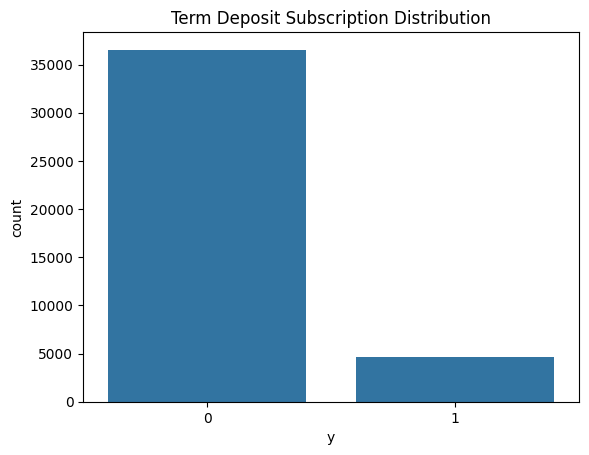

In [ ]:
sn.countplot(data=df,x='y')
plt.title('Term Deposit Subscription Distribution')
plt.show()

In [ ]:
for col in ['default','housing','loan','y']:
  print(f"\n{col}:")
  print(df[col].value_counts())


default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan:
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

y:
y
0    36548
1     4640
Name: count, dtype: int64


In [ ]:
for col in categorical_cols:
  df[col]=df[col].astype(str).str.strip()

In [ ]:
df['job'].unique()

array(['blue-collar', 'technician', 'management', 'services', 'retired',
       'admin.', 'housemaid', 'unemployed', 'entrepreneur',
       'self-employed', 'unknown', 'student'], dtype=object)

In [ ]:
for col in categorical_cols:
  df[col]=df[col].str.lower()

In [ ]:
df['job'].unique()

array(['blue-collar', 'technician', 'management', 'services', 'retired',
       'admin.', 'housemaid', 'unemployed', 'entrepreneur',
       'self-employed', 'unknown', 'student'], dtype=object)

In [ ]:
numeric_cols = [
'age','campaign','pdays','previous','emp_var_rate','cons_price_idx','cons_conf_idx','euribor3m','nr_employed' ]

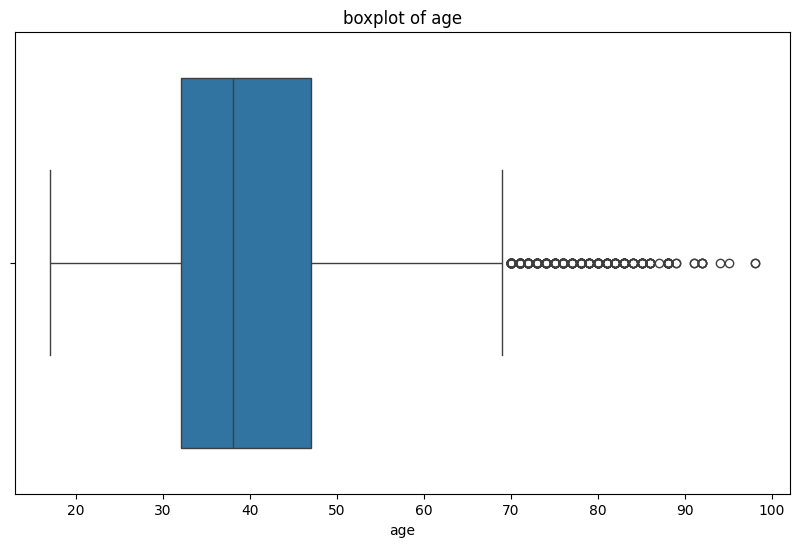

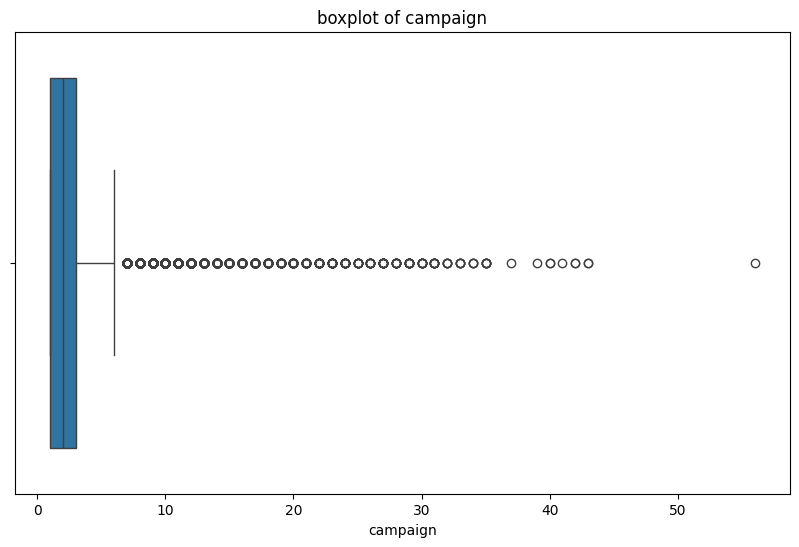

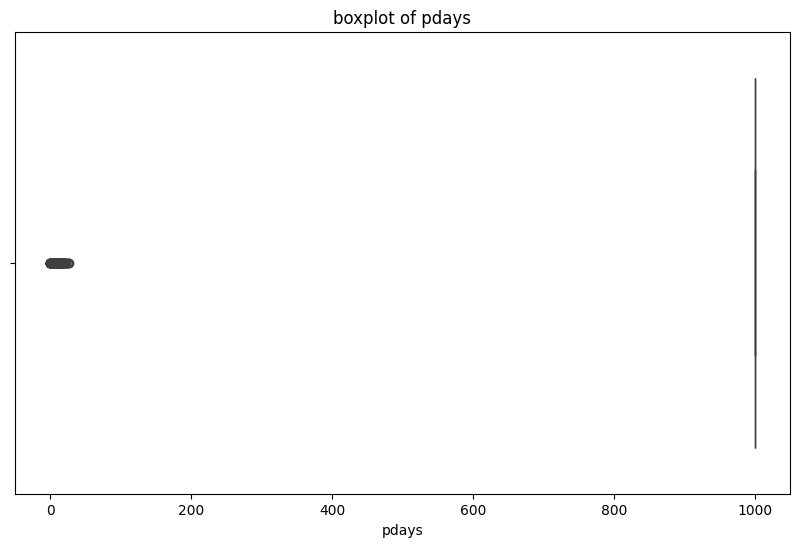

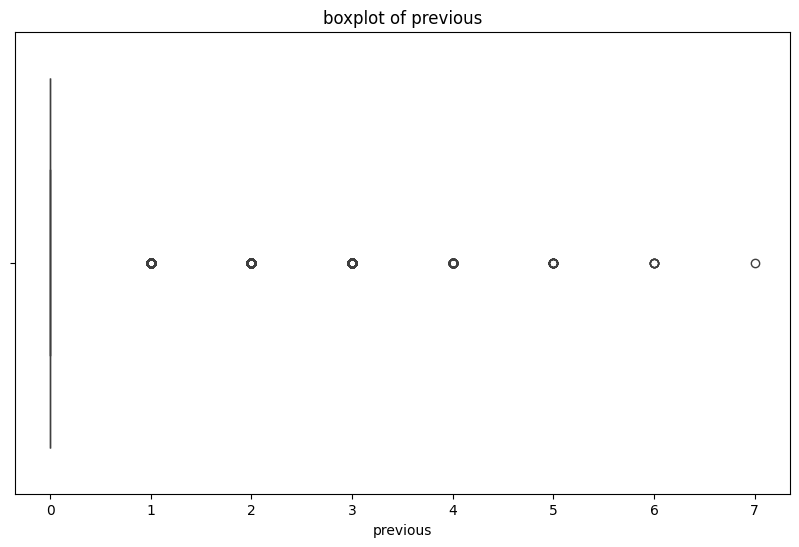

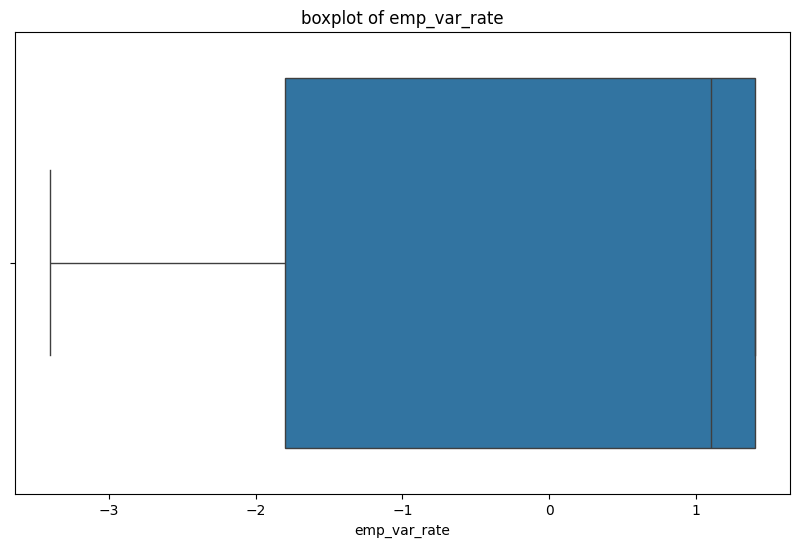

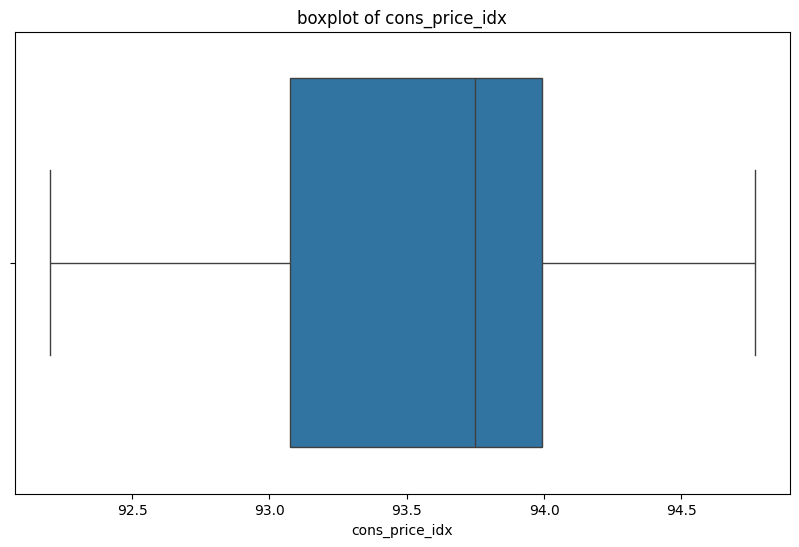

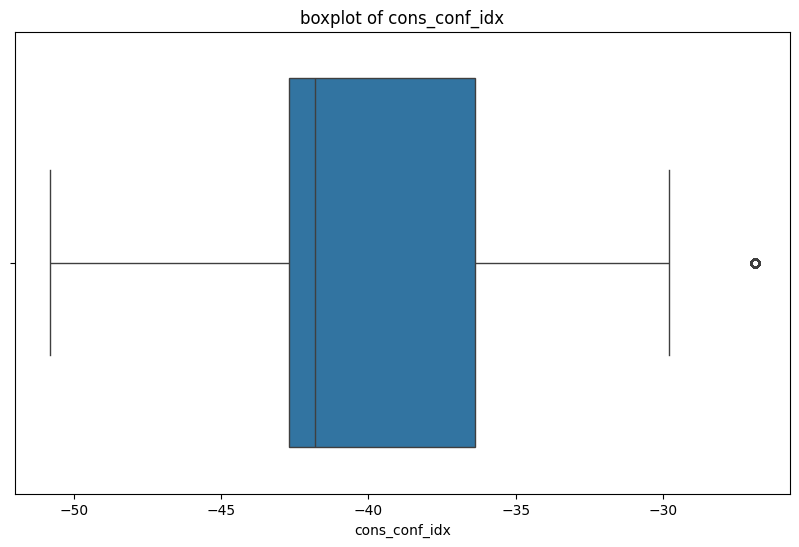

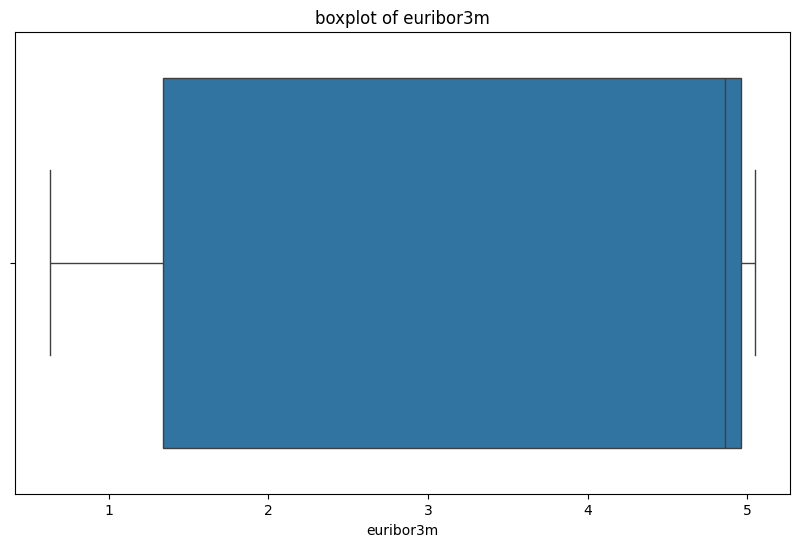

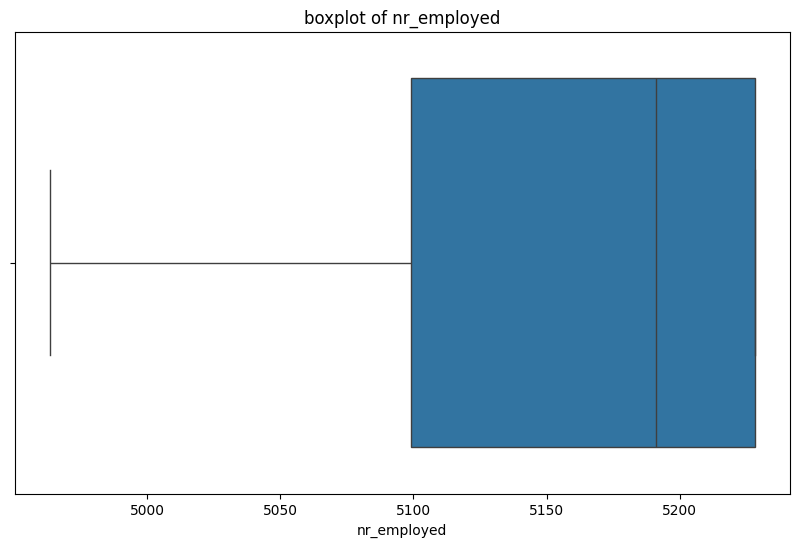

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(10,6))
  sn.boxplot(x=df[col])
  plt.title(f'boxplot of {col}')
  plt.show()

In [ ]:
checks = {
    'age_invalid': ((df['age'] < 18) | (df['age'] > 100)).sum(),
    'campaign_invalid': (df['campaign'] < 1).sum(),
    'previous_invalid': (df['previous'] < 0).sum(),
    'pdays_invalid': (df['pdays'] < 0).sum()
}


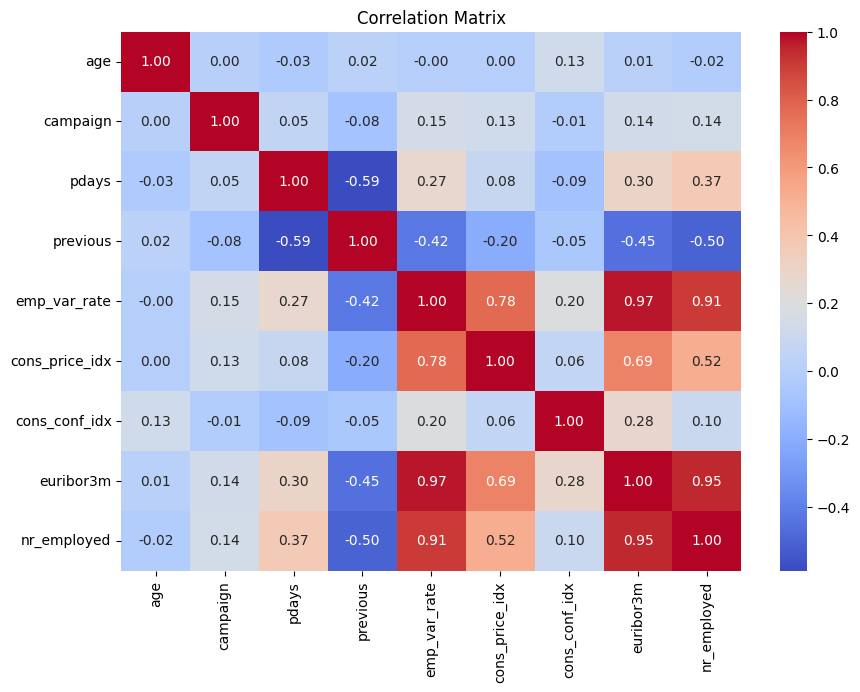

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sn.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.astype(str).values,
    'Missing_Count': df.isnull().sum().values,
    'Missing_%': (df.isnull().mean() * 100).round(2).values,
    'Unique_Values': df.nunique().values
})

In [ ]:
quality_report.to_csv(
    'data_quality_report.csv',
    index=False
)

In [ ]:
df.to_csv(
    'bank_marketing_cleaned.csv',
    index=False
)

In [ ]:
from google.colab import files
files.download('bank_marketing_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
bm = pd.read_csv('/content/bank_marketing_cleaned.csv')


In [ ]:
bm

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,previously_contacted
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,No
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,No
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1,Yes
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,No
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59,retired,married,high.school,unknown,no,yes,telephone,jun,thu,...,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0,No
41184,31,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,...,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0,No
41185,42,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,No
41186,48,technician,married,professional.course,no,no,yes,telephone,oct,tue,...,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0,No


In [ ]:
bm.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,previously_contacted
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,No
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,No
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1,Yes
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,No
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1,Yes


In [ ]:
bm.shape

(41188, 22)

In [ ]:
print("Rows:", bm.shape[0])
print("Columns:", bm.shape[1])
print("Duplicates:", bm.duplicated().sum())
print("Missing values:", bm.isnull().sum().sum())

Rows: 41188
Columns: 22
Duplicates: 12
Missing values: 0


In [ ]:
bm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   41188 non-null  int64  
 1   job                   41188 non-null  object 
 2   marital               41188 non-null  object 
 3   education             41188 non-null  object 
 4   default               41188 non-null  object 
 5   housing               41188 non-null  object 
 6   loan                  41188 non-null  object 
 7   contact               41188 non-null  object 
 8   month                 41188 non-null  object 
 9   day_of_week           41188 non-null  object 
 10  duration              41188 non-null  int64  
 11  campaign              41188 non-null  int64  
 12  pdays                 41188 non-null  int64  
 13  previous              41188 non-null  int64  
 14  poutcome              41188 non-null  object 
 15  emp_var_rate       

In [ ]:
numeric_cols = [
    'age',
    'campaign',
    'pdays',
    'previous',
    'emp_var_rate',
    'cons_price_idx',
    'cons_conf_idx',
    'euribor3m',
    'nr_employed'
]

categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day_of_week',
    'poutcome',
    'y'
]

In [ ]:
print('Numerical Columns:')
print(numeric_cols)
print('\nCategorical Columns:')
print(categorical_cols)

Numerical Columns:
['age', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [ ]:
bm['y'].value_counts()

,count
y,
0,36548
1,4640


In [ ]:
target_distribution=(
    bm['y'].value_counts(normalize=True).mul(100).round(2)
)

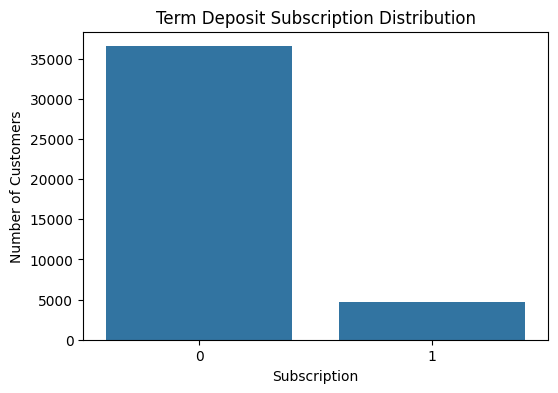

In [ ]:
plt.figure(figsize=(6, 4))

sn.countplot(data=df, x='y')

plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')

plt.show()

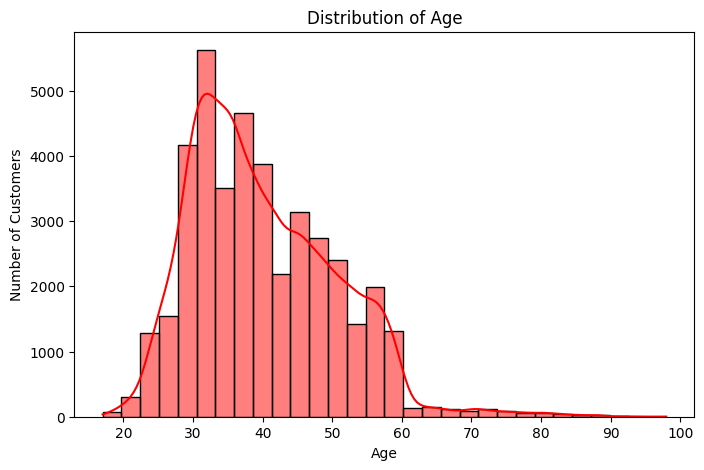

In [ ]:
plt.figure(figsize=(8,5))
sn.histplot(
    data=bm,
    x='age',
    bins=30,
    kde=True,
    color='red'
)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
bm['age'].describe()

,age
count,41188.00000
mean,40.02406
std,10.42125
min,17.00000
25%,32.00000
50%,38.00000
75%,47.00000
max,98.00000


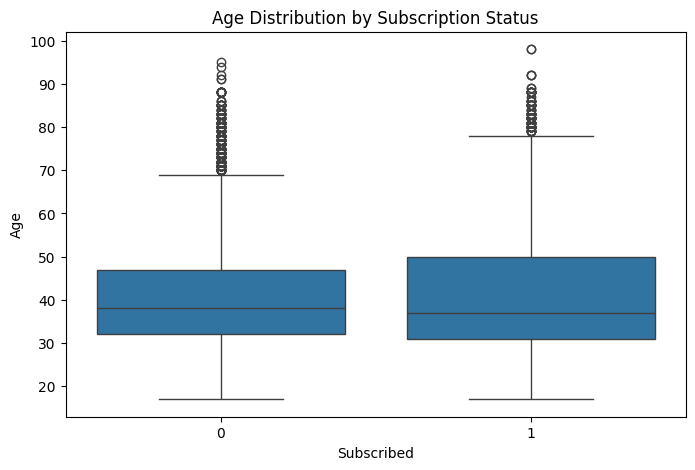

In [ ]:
plt.figure(figsize=(8, 5))

sn.boxplot(
    data=bm,
    x='y',
    y='age'
)

plt.title('Age Distribution by Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Age')

plt.show()

In [ ]:
bm.groupby('y')['age'].agg(
    ['count','mean','median','std']
)

,count,mean,median,std
y,,,,
0,36548,39.911185,38.0,9.898132
1,4640,40.913147,37.0,13.837476


In [ ]:
job_counts= bm['job'].value_counts()

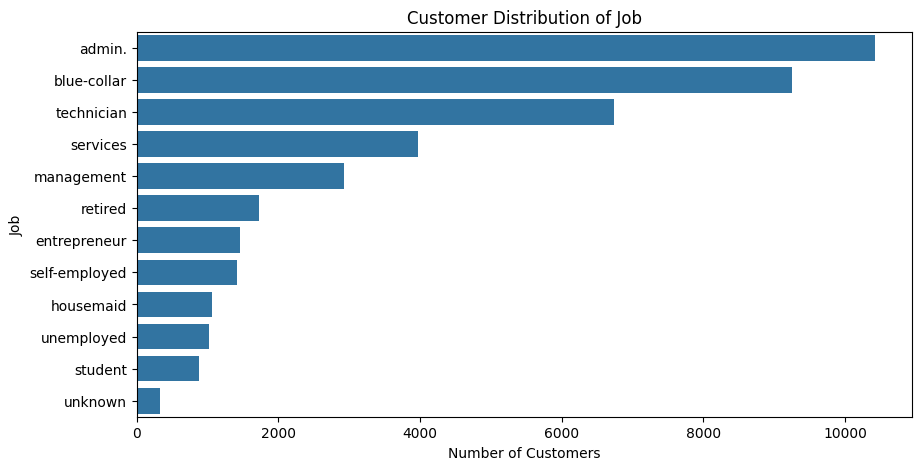

In [ ]:
plt.figure(figsize=(10, 5))

sn.countplot(
    data=bm,
    y='job',
    order= bm['job'].value_counts().index
)

plt.title('Customer Distribution of Job')
plt.xlabel('Number of Customers')
plt.ylabel('Job')

plt.show()

In [ ]:
job_subscription = (
    bm.groupby('job')['y']
    .value_counts(normalize =True)
      .unstack(fill_value = 0)
)


In [ ]:
job_subscription_rate = (
    job_subscription[1]*100
).sort_values(ascending=False)

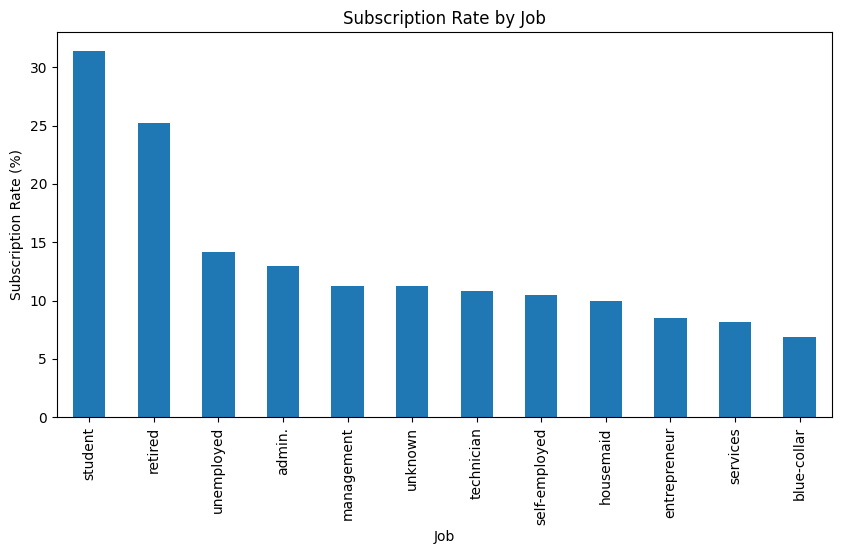

In [ ]:
plt.figure(figsize=(10, 5))

job_subscription_rate.plot(kind='bar')

plt.title('Subscription Rate by Job')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=90)

plt.show()

In [ ]:
bm['marital'].value_counts()

,count
marital,
married,24928
single,11568
divorced,4612
unknown,80


In [ ]:
marital_subscription = (
    bm.groupby('marital')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)

)

<Figure size 700x400 with 0 Axes>

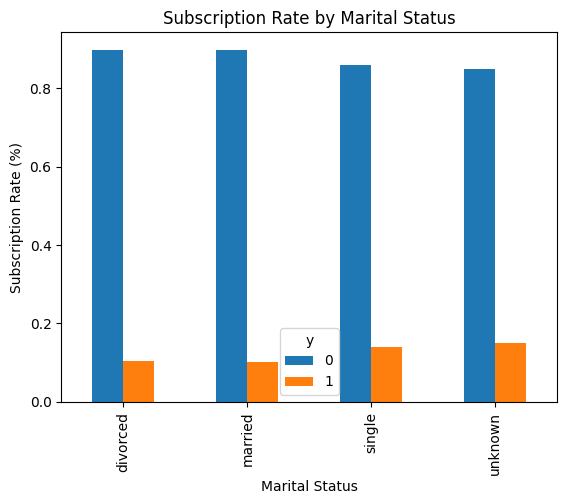

In [ ]:
plt.figure(figsize=(7, 4))

marital_subscription.plot(kind='bar')

plt.title('Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Subscription Rate (%)')

plt.show()

In [ ]:
education_subscription = (
    bm.groupby('education')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)
)

<Figure size 1000x500 with 0 Axes>

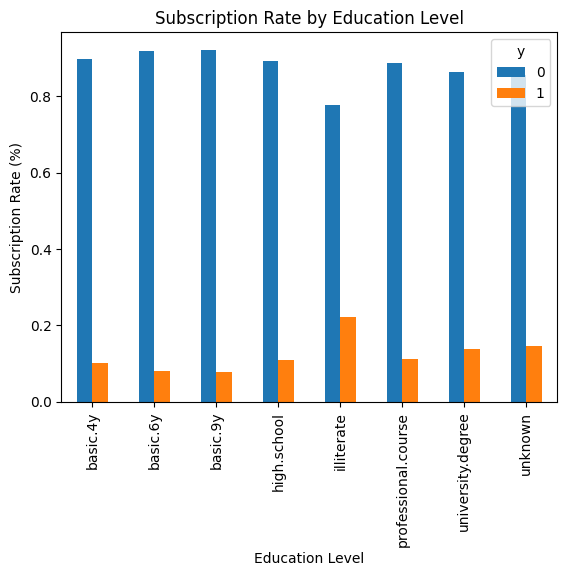

In [ ]:
plt.figure(figsize=(10, 5))

education_subscription.plot(kind='bar')

plt.title('Subscription Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Subscription Rate (%)')

plt.show()

In [ ]:
bm['loan'].value_counts()

,count
loan,
no,33950
yes,6248
unknown,990


In [ ]:
loan_subscription = (
    bm.groupby('loan')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)

)

In [ ]:
housing_subscription = (
    bm.groupby('housing')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)

)

In [ ]:
default_subscription=(
    bm.groupby('default')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)
)

In [ ]:
loan_y = pd.crosstab(
    bm['loan'],
    bm['y'],
    normalize='index'
) * 100


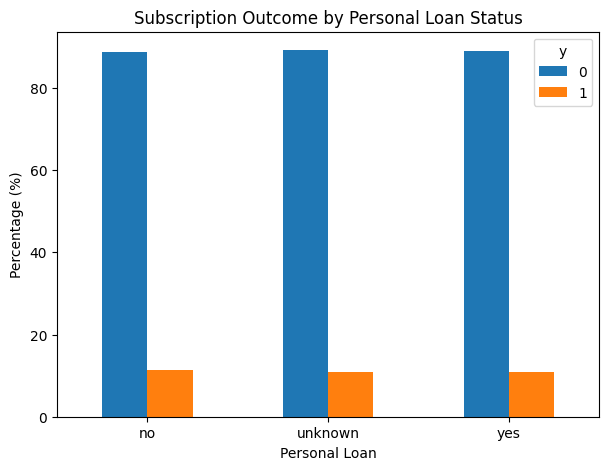

In [ ]:
loan_y.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Subscription Outcome by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=0)

plt.show()

In [ ]:
bm['campaign'].describe()

,campaign
count,41188.000000
mean,2.567593
std,2.770014
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,56.000000


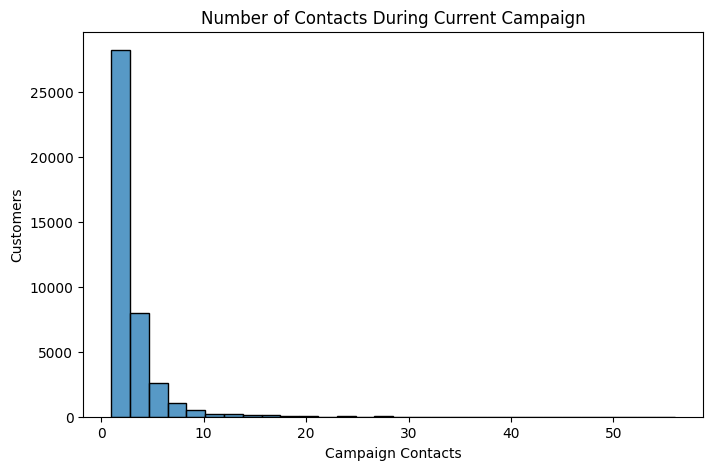

In [ ]:
plt.figure(figsize=(8, 5))

sn.histplot(
    data=bm,
    x='campaign',
    bins=30
)

plt.title('Number of Contacts During Current Campaign')
plt.xlabel('Campaign Contacts')
plt.ylabel('Customers')

plt.show()

In [ ]:
campaign_subscription = (
    df.groupby('y')['campaign']
      .agg(['count', 'mean', 'median', 'std'])
)

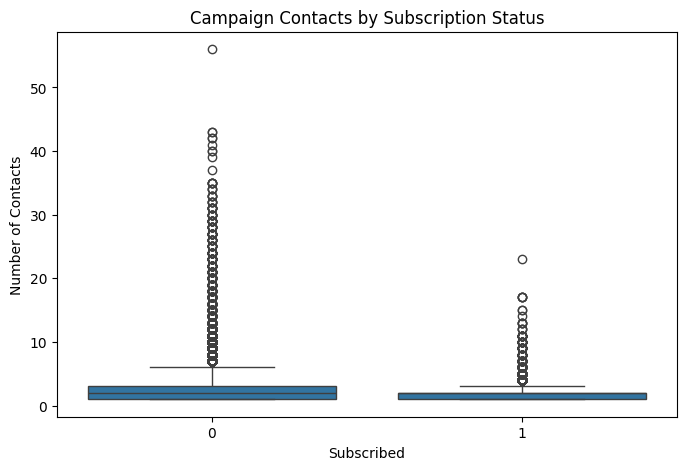

In [ ]:
plt.figure(figsize=(8, 5))

sn.boxplot(
    data=bm,
    x='y',
    y='campaign'
)

plt.title('Campaign Contacts by Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Number of Contacts')

plt.show()

In [ ]:
bm['previous'].describe()

,previous
count,41188.000000
mean,0.172963
std,0.494901
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7.000000


In [ ]:
bm['poutcome'].value_counts()

,count
poutcome,
nonexistent,35563
failure,4252
success,1373


In [ ]:
poutcome_subscription=(
    bm.groupby('poutcome')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)

)

<Figure size 800x500 with 0 Axes>

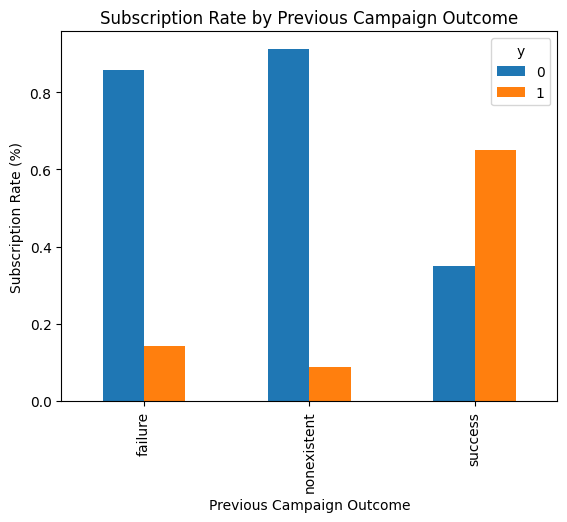

In [ ]:
plt.figure(figsize=(8, 5))

poutcome_subscription.plot(kind='bar')

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')

plt.show()

In [ ]:
contact_subscription = (
    bm.groupby('contact')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)
)

<Figure size 700x400 with 0 Axes>

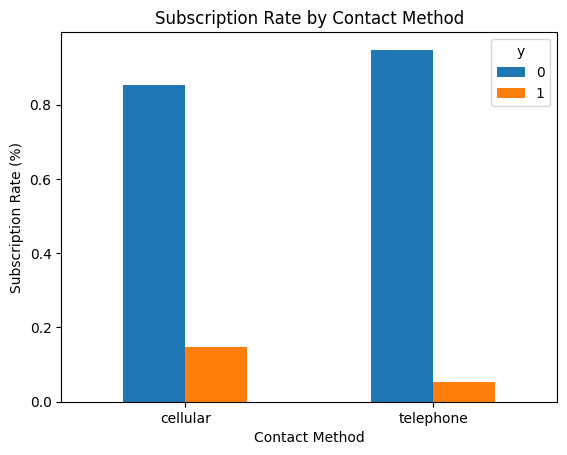

In [ ]:
plt.figure(figsize=(7, 4))

contact_subscription.plot(kind='bar')

plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

In [ ]:
bm['month'].value_counts()

,count
month,
may,13769
jul,7174
aug,6178
jun,5318
nov,4101
apr,2632
oct,718
sep,570
mar,546


In [ ]:
monthly_subscription= (
    bm.groupby('month')['y']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)
)

<Figure size 1000x500 with 0 Axes>

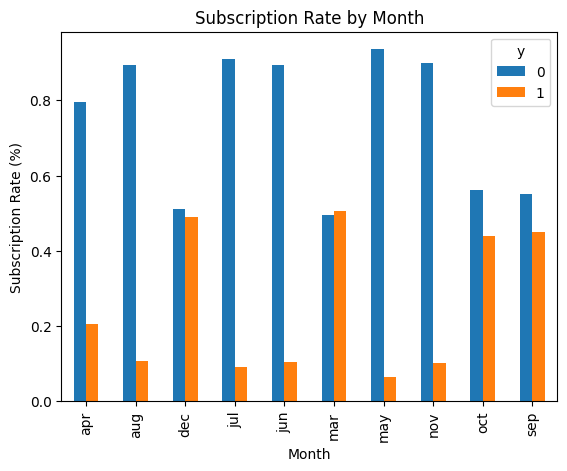

In [ ]:
plt.figure(figsize=(10, 5))

monthly_subscription.plot(kind='bar')

plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate (%)')

plt.show()

In [ ]:
economic_cols = [
    'emp_var_rate',
    'cons_price_idx',
    'cons_conf_idx',
    'euribor3m',
    'nr_employed'
]

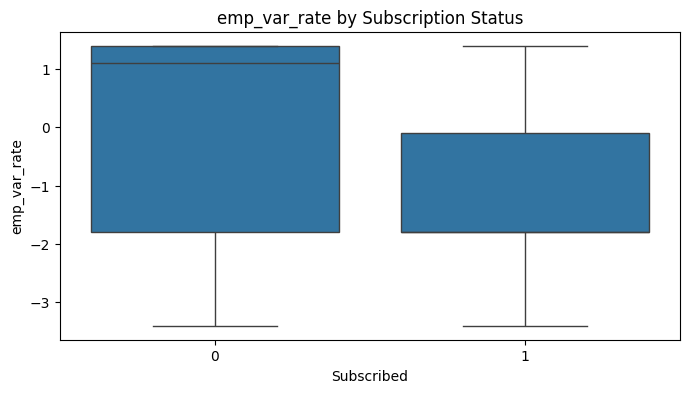

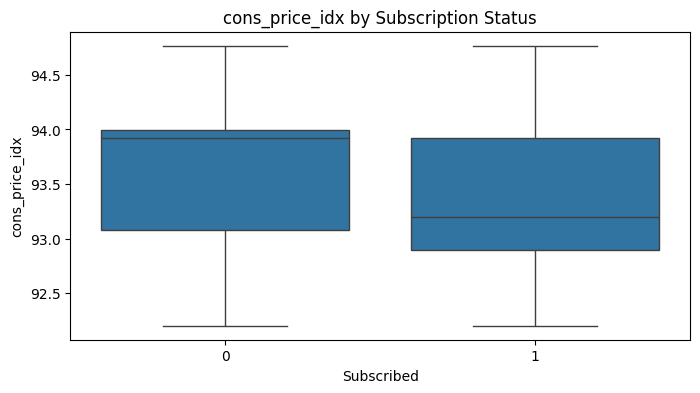

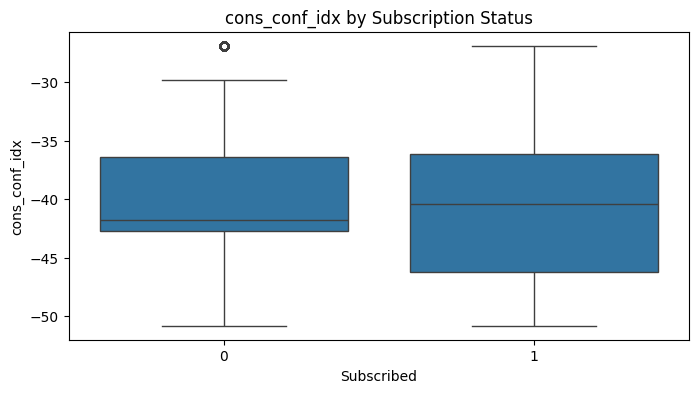

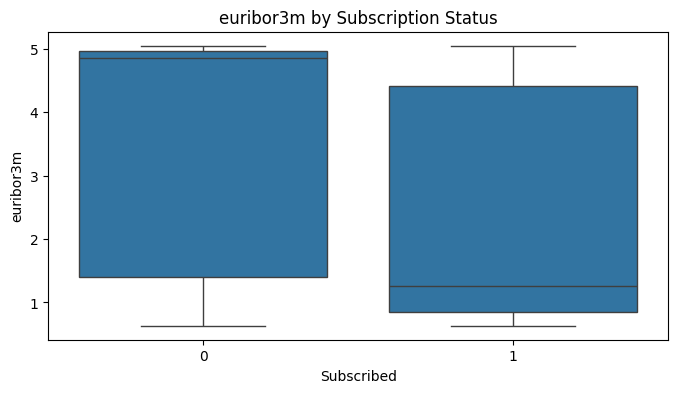

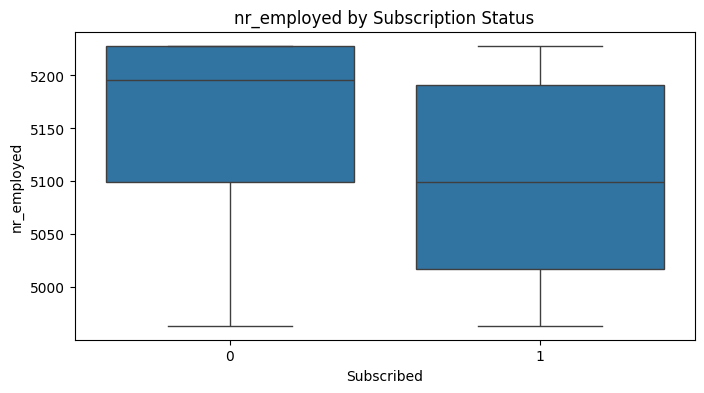

In [ ]:
for col in economic_cols:

    plt.figure(figsize=(8, 4))

    sn.boxplot(
        data=bm,
        x='y',
        y=col
    )

    plt.title(f'{col} by Subscription Status')
    plt.xlabel('Subscribed')
    plt.ylabel(col)

    plt.show()

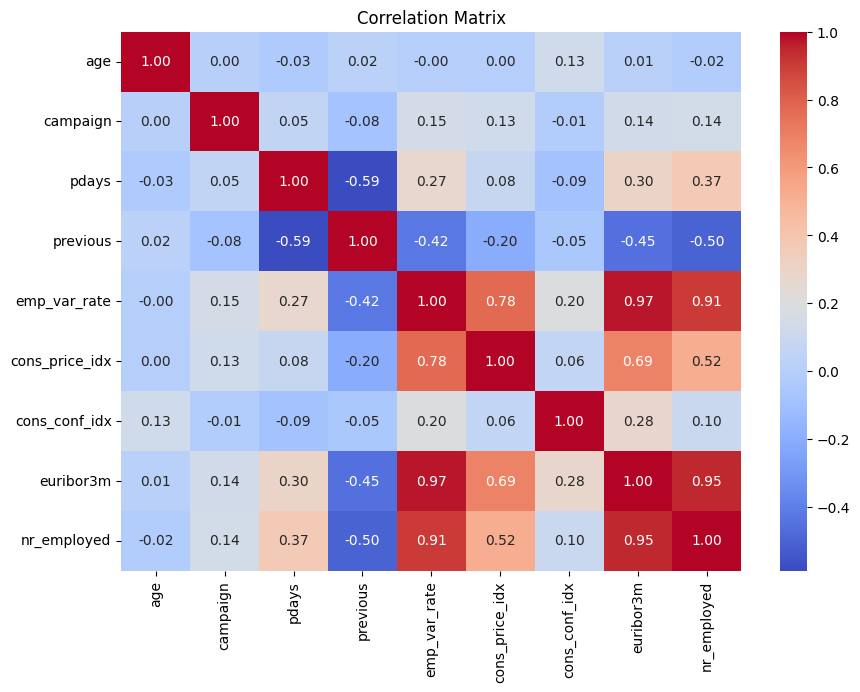

In [ ]:
corr = bm[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sn.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
yes_age= bm[bm['y']=='1']['age']
no_age= bm[bm['y']=='0']['age']

In [ ]:
stat, p_value = stats.mannwhitneyu(yes_age, no_age, alternative='two-sided')
print('Test Statistic:',stat)

Test Statistic: nan


/tmp/ipykernel_969/529991097.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = stats.mannwhitneyu(yes_age, no_age, alternative='two-sided')


In [ ]:
contingency= pd.crosstab(
    bm['loan'],
    bm['y']
)

In [ ]:
chi2,p,dof,expected= stats.chi2_contingency(
    contingency,
    correction=False
)
print('Test Statistic:',chi2)
print('p-values:',p)
print('Degree of freedom:',dof)

Test Statistic: 1.094027551150338
p-values: 0.5786752870441754
Degree of freedom: 2


In [ ]:
contingency= pd.crosstab(
    bm['housing'],
    bm['y']
)
chi2,p,dof,expected=stats.chi2_contingency(
    contingency
)
print('Chi-square:',chi2)
print('p-value:',p)

Chi-square: 5.684495858974168
p-value: 0.05829447669453452


In [ ]:
contingency= pd.crosstab(
    bm['job'],
    bm['y']
)
chi2,p,dof,expected=stats.chi2_contingency(
    contingency
)
print('chi-square:',chi2)
print('p-value:',p)

chi-square: 961.2424403289555
p-value: 4.189763287563623e-199


In [102]:
from google.colab import files
files.download('bank_marketing_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>